# parcellate SUVRs in MNI152 

1. read parcellater 
2. glob.glob
3. parcellate each 
4. create a pandas df
5. stats 
6. plot

In [1]:
from neuromaps.parcellate import Parcellater
import glob, os 
import numpy as np
import nibabel as nb
import pandas as pd
from scipy.stats import ttest_1samp
from neuromaps.datasets import fetch_fsaverage
from surfplot import Plot


In [2]:
BASE_PATH = os.path.dirname(os.getcwd())
SUVRs = BASE_PATH + '/SUVRs/'

In [3]:
files = []
for f in os.listdir(SUVRs): 
    if 'mni152.2mm.sm00.nii.gz' in f:
        files.append(f)
files.sort()

In [4]:
atlas =  BASE_PATH + '/annot/glasser_MNI152NLin6Asym_labels_p20_2mm.nii.gz'
parcellater_mni = Parcellater(atlas, 'MNI152')


In [5]:
# parcellate active and sham separately
active = []
sham= []
for file in files:
    full_file = SUVRs + '/' + file
    parc = parcellater_mni.fit_transform(full_file, space='MNI152', ignore_background_data=True)
    if "active" in file:
        active.append(parc[0])
    else:
        sham.append(parc[0])
    

active_data = np.column_stack(active)
sham_data = np.column_stack(sham)

# create dataframes
names = [file.split('_')[0] for file in files]
names = np.unique(names)
df_active = pd.DataFrame(active_data, columns=names)
df_sham = pd.DataFrame(sham_data, columns=names)

# contrast
df_contrast = df_active - df_sham


In [6]:
df_contrast

,tbsfdg001,tbsfdg002,tbsfdg004,tbsfdg005,tbsfdg006,tbsfdg007,tbsfdg008,tbsfdg009,tbsfdg010,tbsfdg011,tbsfdg015,tbsfdg019,tbsfdg021,tbsfdg023,tbsfdg031,tbsfdg034
0,0.013490,-0.008597,0.010815,-0.047123,0.055813,0.007997,-0.008265,-0.039927,0.036422,-0.040360,0.008470,0.004359,-0.010845,0.047016,0.017088,-0.025516
1,-0.000330,0.040498,0.021824,-0.024350,0.025944,0.021537,-0.011100,-0.028037,0.010272,-0.019794,0.012921,0.005704,-0.025314,0.003140,0.029729,-0.025408
2,0.013074,0.014217,-0.006567,-0.039743,0.056161,0.017808,0.002411,-0.010337,-0.050343,0.018428,-0.011595,-0.027916,-0.008354,-0.012423,0.004663,-0.015098
3,0.021078,0.002632,0.004168,-0.028629,0.076003,0.012408,-0.005464,-0.040822,0.014647,-0.040290,0.011232,-0.006249,-0.009381,0.019215,0.012811,-0.026500
4,0.023737,0.014495,-0.004099,-0.024363,0.048094,0.003480,-0.007343,-0.034885,0.005828,-0.041162,0.017318,-0.002610,-0.009537,0.013509,0.004530,-0.030850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,-0.013542,-0.000460,0.020374,0.034646,-0.042602,0.009647,-0.000305,-0.010289,0.000154,-0.022993,-0.014996,-0.009770,-0.001863,-0.050165,-0.021765,0.014914
356,-0.011893,-0.049269,-0.027063,0.010267,-0.056172,-0.001631,-0.019766,-0.048544,-0.017605,-0.065480,0.011667,0.022536,0.021161,-0.032438,-0.014321,0.000943
357,0.019155,0.013398,0.032308,0.015806,-0.030522,0.012003,-0.013920,0.012713,-0.011009,-0.001343,-0.004987,-0.005811,-0.002858,0.012363,-0.012694,0.024190
358,0.006467,-0.021683,0.002669,-0.019531,-0.008788,-0.030252,-0.028017,0.046168,0.008952,0.032653,0.015092,-0.026024,0.022048,0.001041,-0.002432,-0.001433


In [7]:
# do test
results = df_contrast.apply(lambda row: ttest_1samp(row, popmean=0), axis=1) 


In [8]:
res =pd.DataFrame()
res['t-stat'] = results.apply(lambda res: res.statistic)
res['p-val'] = results.apply(lambda res: res.pvalue)
sum(res['p-val'] < 0.05)

29

In [9]:
# make those dicts 
dict_lh = res.loc[0:179, 'p-val']
dict_lh.index =  range(1, len(dict_lh) + 1)
dict_lh = dict_lh.to_dict()

dict_rh = res.loc[180::, 'p-val']
dict_rh.index =  range(1, len(dict_rh) + 1)
dict_rh = dict_rh.to_dict()

In [10]:
# get labels 
lh_labels, _,_  =  nb.freesurfer.io.read_annot(BASE_PATH + '/annot/lh.HCPMMP1.annot')
rh_labels, _ , _ =  nb.freesurfer.io.read_annot(BASE_PATH + '/annot/rh.HCPMMP1.annot')
#magic
lh_map = np.array([0 if v == 0 else dict_lh[v] for v in lh_labels])
rh_map = np.array([0 if v == 0 else dict_rh[v] for v in rh_labels])
map = {'left': lh_map, 'right': rh_map}

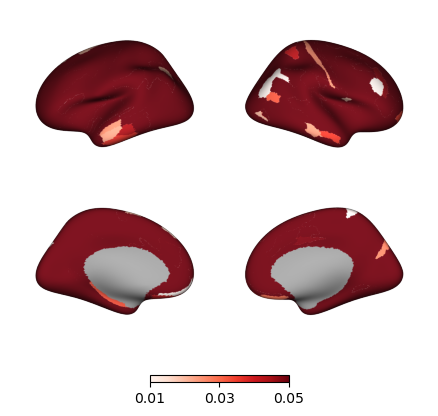

In [11]:
surface = fetch_fsaverage(density='164k')
lh, rh = surface['inflated']

p = Plot(lh, rh, views=['lateral','medial'], zoom=1.2)
p.add_layer(map, color_range=(0.01,0.05), cmap='Reds', cbar=True,zero_transparent=True  )
pic = p.build()

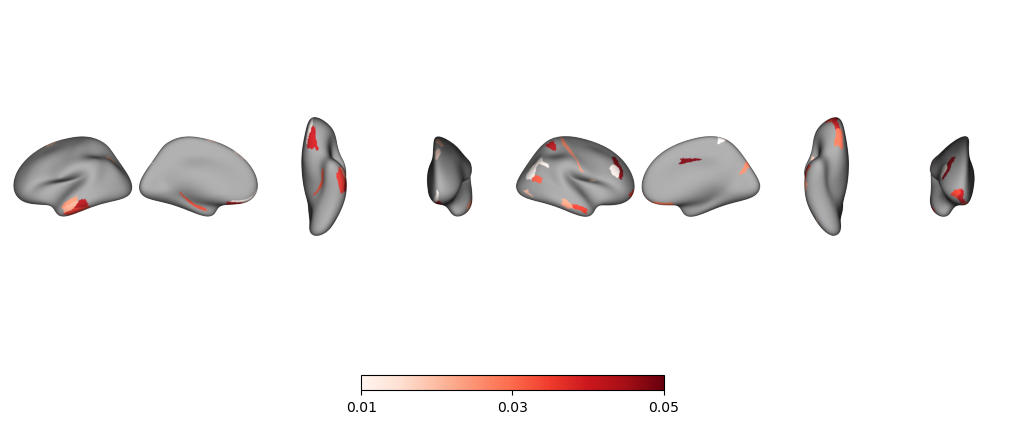

In [12]:
lh_map_thr = (lh_map < 0.05) * lh_map
rh_map_thr = (rh_map < 0.05) * rh_map
map = {'left': lh_map_thr, 'right': rh_map_thr}
p = Plot(lh, rh, views=['lateral','medial', 'ventral', 'anterior'], layout='row',zoom=1.2, size=(1200, 400))
p.add_layer(map, color_range=(0.01,0.05), cmap='Reds', cbar=True,zero_transparent=True  )
pic = p.build()